In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def function(x):
    f = np.tan(x)
    return f 

In [34]:
n = 6
x_values = np.linspace(-1.5,1.5, n)
y_values = function(x_values)


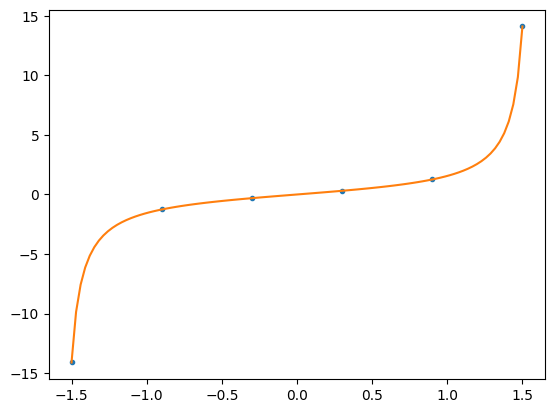

In [35]:
plt.plot(x_values,y_values, '.')
plt.plot(np.linspace(-1.5, 1.5, 100), np.tan(np.linspace(-1.5,1.5,100)))

In [36]:
def poly_Tn(x,n):
    if n == 0:
        return 1
    elif n == 1:
        return x
    T = [1, x]  # T[0] = 1, T[1] = x
    for i in range(2, n + 1):
        T.append(2 * x * T[i - 1] - T[i - 2])
    return T[n]
def poly_chebushova(x_values, y_values):
    a = np.min(x_values)
    b = np.max(x_values)
    n = len(x_values)
    x_new = []
    for i in range(n):
        x = np.cos(np.pi * (2*i+1) / (2*n))
        x_new.append( (a+b)/2 + (b-a) * x / 2)
    y_values = np.tan(x_new)
    coeffs = []
    for j in range(n):
        A = 0
        for k in range(n):
            t_k = (2 * x_new[k] - (a + b)) / (b - a)
            T = poly_Tn(t_k, j)
            A += y_values[k] * T  #Считаем a_j
            # Нормировка коэффициента
        if j == 0:
            coeffs.append(A / n)
        else:
            coeffs.append(2 * A / n)
    return coeffs
def create_poly_chebuschova(x_values,y_values):
    a = np.min(x_values)
    b = np.max(x_values)
    coeff = poly_chebushova(x_values, y_values)
    def poly_Ln(x):
        result = 0
        t = (2 * x - (a + b)) / (b - a)
        for i in range(len(coeff)):
            T = poly_Tn(t, i)
            result += coeff[i] * T
        return result
    return poly_Ln

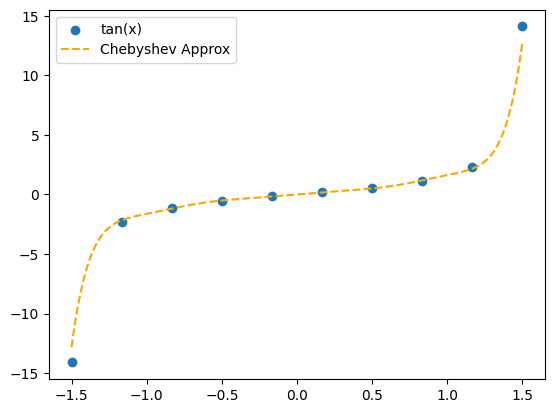

In [37]:
x_values = np.linspace(-1.5, 1.5, 10)  
y_values = np.tan(x_values)

cheb_poly = create_poly_chebuschova(x_values, y_values)

# График
x = np.linspace(-1.5, 1.5, 500)
plt.scatter(x_values, y_values, label='tan(x)')
plt.plot(x, cheb_poly(x), '--', label='Chebyshev Approx', color='orange')
plt.legend()
plt.show()